In [56]:
#importando as bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
#Renomeando a planilha de dados
arquivo='../refs/Eficiencia Operacional em Linhas de Producao.xlsx'

In [49]:
#lendo os dados da planilha
df=pd.read_excel(arquivo)
df

,Nivel_Automacao,Tempo_Ciclo_s,Unidades_Produzidas
0,Alta,52.42,523
1,Baixa,43.03,643
2,Média,58.33,421
3,Baixa,55.95,495
4,Alta,36.54,832
...,...,...,...
995,Baixa,54.31,446
996,Média,49.62,601
997,Alta,51.04,597
998,Média,57.56,400


Calculo de Q1 (25%), Q2 (50% - Mediana) e Q3 (75%)

In [50]:
df.Unidades_Produzidas.describe().round(3)

count    1000.000
mean      621.695
std       170.941
min       211.000
25%       499.000
50%       601.000
75%       733.000
max      1200.000
Name: Unidades_Produzidas, dtype: float64

In [51]:
Q1 = df.Unidades_Produzidas.quantile(q=0.25).round(3)
Q2 = df.Unidades_Produzidas.quantile(q=0.50).round(3)
Q3 = df.Unidades_Produzidas.quantile(q=0.75).round(3)
AIQ = Q3 - Q1
print(f'Q1: {Q1} unidades \nQ2: {Q2} unidades\nQ3: {Q3} unidades\nIQR = Q3 - Q1 = {AIQ} unidades')

Q1: 499.0 unidades 
Q2: 601.0 unidades
Q3: 733.0 unidades
IQR = Q3 - Q1 = 234.0 unidades


#### Conclusão e interpretação das separatrizes:

- **Q1 (499 unidades):** 25% dos registros produziram até 499 unidades no ciclo observado; os outros 75% produziram valores iguais ou superiores a isso.
- **Q2 / Mediana (601 unidades):** metade das observações produziu até 601 unidades e a outra metade produziu mais que isso. Como é a mediana, esse valor divide o conjunto de dados ao meio e é menos sensível a valores extremos do que a média.
- **Q3 (733 unidades):** 75% dos registros produziram até 733 unidades, restando apenas 25% das observações com produção acima desse patamar.
- **Amplitude Interquartil (IQR = 234 unidades):** representa a faixa onde se concentram os 50% centrais dos dados (entre Q1 e Q3), sendo uma medida de dispersão mais robusta que a amplitude total, pois não é influenciada por outliers.

### **Boxplot**

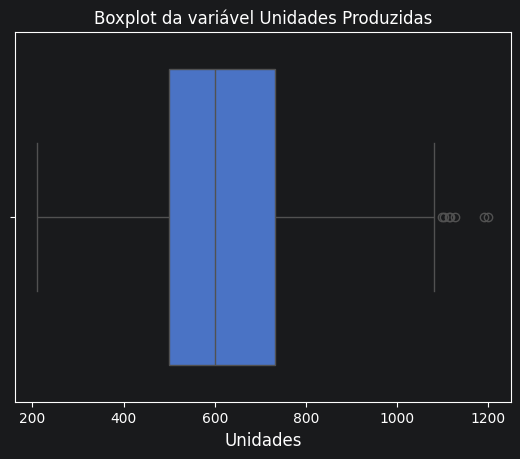

In [52]:
sns.boxplot(data=df.Unidades_Produzidas, orient="h")
plt.xlabel('Unidades',fontsize=12)
plt.title('Boxplot da variável Unidades Produzidas',fontsize=12)
plt.show()

### **Boxplot Comparativo**

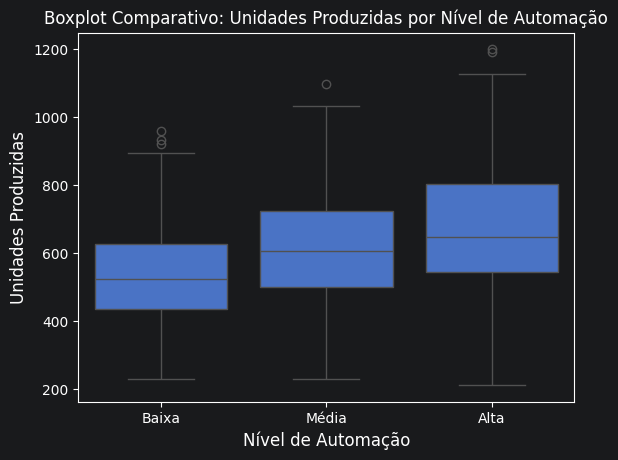

In [59]:
# Ordenando os níveis de automação para exibição correta no boxplot
ordem_automacao = pd.CategoricalDtype(categories=['Baixa', 'Média', 'Alta'], ordered=True)
df['Nivel_Automacao'] = df['Nivel_Automacao'].astype(ordem_automacao)

sns.boxplot(data=df, x='Nivel_Automacao', y='Unidades_Produzidas', order=['Baixa', 'Média', 'Alta'])
plt.xlabel('Nível de Automação', fontsize=12)
plt.ylabel('Unidades Produzidas', fontsize=12)
plt.title('Boxplot Comparativo: Unidades Produzidas por Nível de Automação', fontsize=12)
plt.show()

In [61]:
mediana_baixa = df[df.Nivel_Automacao=='Baixa'].Unidades_Produzidas.median().round(3)
mediana_media = df[df.Nivel_Automacao=='Média'].Unidades_Produzidas.median().round(3)
mediana_alta  = df[df.Nivel_Automacao=='Alta'].Unidades_Produzidas.median().round(3)

# Calculando os quartis 1 e 3 de unidades produzidas com baixo nivel de automação
Q1_baixa = df[df.Nivel_Automacao=='Baixa'].Unidades_Produzidas.quantile(q=0.25)
Q3_baixa = df[df.Nivel_Automacao=='Baixa'].Unidades_Produzidas.quantile(q=0.75)
IQR_baixa = (Q3_baixa - Q1_baixa).round(3)

# Calculando os quartis 1 e 3 de unidades produzidas com médio nivel de automação
Q1_media = df[df.Nivel_Automacao=='Média'].Unidades_Produzidas.quantile(q=0.25)
Q3_media = df[df.Nivel_Automacao=='Média'].Unidades_Produzidas.quantile(q=0.75)
IQR_media = (Q3_media - Q1_media).round(3)

Q1_alta = df[df.Nivel_Automacao=='Alta'].Unidades_Produzidas.quantile(q=0.25)
Q3_alta = df[df.Nivel_Automacao=='Alta'].Unidades_Produzidas.quantile(q=0.75)
IQR_alta = (Q3_alta - Q1_alta).round(3)

print(f'Mediana (unidades) -> Baixa: {mediana_baixa} | Média: {mediana_media} | Alta: {mediana_alta}')
print(f'IQR (unidades) -> Baixa: {IQR_baixa} | Média: {IQR_media} | Alta: {IQR_alta}')

Mediana (unidades) -> Baixa: 524.5 | Média: 606.0 | Alta: 647.0
IQR (unidades) -> Baixa: 192.5 | Média: 222.0 | Alta: 256.5


#### **Interpretação do boxplot comparativo**

- **Mediana crescente:** a produção mediana sobe de **524,5 unidades** (Baixa automação) para **606,0** (Média) e **647,0** (Alta) — quanto maior o nível de automação, maior o volume produzido por ciclo.
- **Dispersão também crescente:** o IQR cresce na mesma direção (192,5 → 222,0 → 256,5 unidades), ou seja, Alta automação produz mais, mas com maior variabilidade entre ciclos do que Baixa automação.

### **Cálculo de Outlier**

In [53]:
# Calculando os limites superiores e inferiores de outliers
linf = Q1 - 1.5*AIQ
lsup = Q3 + 1.5*AIQ

# Resumo e quantidade de outliers
outliers_superiores = df[df.Unidades_Produzidas> lsup]
outliers_inferiores = df[df.Unidades_Produzidas< linf]

print(f'Limite inferior de outlier = {linf.round(3)}')
print(f'Limite superior de outlier = {lsup.round(3)}')
print(f'Total de outliers: {len(outliers_superiores)+len(outliers_inferiores)}')
print(f'Total de outliers superiores: {len(outliers_superiores)}')
print(f'Total de outliers inferiores: {len(outliers_inferiores)}')

Limite inferior de outlier = 148.0
Limite superior de outlier = 1084.0
Total de outliers: 7
Total de outliers superiores: 7
Total de outliers inferiores: 0


#### Conclusão e interpretação do boxplot e outliers

O boxplot da variável Unidades_Produzidas mostra uma **caixa central razoavelmente simétrica** (mediana em 601 unidades, próxima ao centro entre Q1 = 499 e Q3 = 733), mas o **limite superior é visivelmente maior que o limite inferior**, e há **7 outliers**, todos acima do limite superior de 1084 unidades (variando de 1098 a 1200 unidades) — não há nenhum outlier abaixo do limite inferior de 148 unidades.

Esse padrão indica uma **leve assimetria à direita (positiva)** na distribuição: a maior parte dos dados se concentra entre ~500 e ~730 unidades, mas existem alguns registros de produção excepcionalmente alta que puxam a cauda direita da distribuição, sem um efeito equivalente do lado esquerdo (nenhuma produção anormalmente baixa foi identificada como outlier).

Do ponto de vista prático, esses 7 outliers podem representar ciclos de produção com desempenho atípico — por exemplo, lotes menores/mais rápidos, ajustes de máquina, ou possíveis erros de registro — e merecem uma verificação pontual, mas não chegam a comprometer a leitura geral da variável, já que representam menos de 1% das 1000 observações.

### Calculando e encontrando a variabilidade dos dados (desvio padrão + variação)

In [58]:
desvio_padrao = df.Unidades_Produzidas.std().round(3)
media = df.Unidades_Produzidas.mean().round(3)
coeficiente_de_variacao = (desvio_padrao / media * 100).round(2)

print(f'Desvio padrão (Tempo_Ciclo_s) = {desvio_padrao} unidades')
print(f'Média geral dos dados (Valor Médio): {media} unidades')
print(f'Coeficiente de variação dos dados: {coeficiente_de_variacao} %')

Desvio padrão (Tempo_Ciclo_s) = 170.941 unidades
Média geral dos dados (Valor Médio): 621.695 unidades
Coeficiente de variação dos dados: 27.5 %


#### Interpretação e cconcclusão das métricas de varriabilidade dos dados:

O **desvio padrão** de 170,941 unidades indica que, em média, a produção de cada ciclo se afasta cerca de 171 unidades da média geral (621,695 unidades) — um valor de dispersão relativamente alto em relação à própria escala da variável.

Isso fica mais claro pelo **coeficiente de variação (CV) de 27,5%**: como o CV normaliza o desvio padrão pela média (permitindo comparar a dispersão relativa mesmo entre variáveis com unidades diferentes), esse percentual mostra que Unidades_Produzidas apresenta uma **dispersão moderada a alta**, com bastante variabilidade em torno da média — é coerente com a leve assimetria à direita e os outliers de produção elevada já identificados no boxplot.